# AI Model Engine - Interactive Training & Analysis
Notebook này giúp bạn tải dữ liệu, kiểm tra tính dừng (stationarity), tiến hành huấn luyện RL Agent một cách độc lập không cần server, và thực hiện kiểm định đánh giá hiệu năng chiến lược (Sharpe Ratio, Max Drawdown, NAV vs VN30, Action Distribution).

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import logging
import warnings
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO)

# Tự động tìm và thêm thư mục src/pipeline vào sys.path bất kể notebook chạy ở đâu
current_dir = Path(os.getcwd()).resolve()
possible_paths = [
    current_dir,
    current_dir / "src" / "pipeline",
    current_dir.parent / "src" / "pipeline",
    current_dir.parent.parent / "src" / "pipeline",
    current_dir.parent.parent.parent / "src" / "pipeline"
]
for p in possible_paths:
    if p.exists() and (p / "model_engine").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break


## 1. Load Data

In [2]:
from model_engine.data.data_service import DataQueryService
from model_engine.data.processor import DataProcessor
from core.config.settings import MODEL_CONFIG

train_start = MODEL_CONFIG.get("train_start_date", "2018-06-25")
train_end = MODEL_CONFIG.get("train_end_date", "2020-12-31")

features = MODEL_CONFIG.get("features", [])
query_svc = DataQueryService()
train_raw = query_svc.fetch_data(train_start, train_end)

processor = DataProcessor(train_raw, features)
train_data = processor.clean_data()

print("Data shape after processing:", train_data.shape)
train_data.tail(15)

INFO:model_engine.data.data_service:Fetching data from 2018-06-25 to 2020-12-31...


Data shape after processing: (6350, 16)


,tic,date,open,high,low,close,volume,ADX,ATR,CCI,PPO,RSI,VOLATILITY,DXY_LOG_RETURN,VNIBOR_ON,YIELD_CURVE_SLOPE
6335,VNIND,2020-12-29,647.29,656.27,643.81,654.14,134177280,50.637559,9.840522,133.298296,2.871360,79.179786,0.008650,-0.003659,0.13,1.858
6336,VNIT,2020-12-29,1323.68,1342.79,1316.99,1338.48,3173810,38.380697,22.120661,156.344616,1.504136,67.471535,0.009105,-0.003659,0.13,1.858
6337,VNMAT,2020-12-29,1677.92,1684.85,1662.08,1679.13,55209490,48.498145,36.647645,151.390809,3.659967,74.260038,0.015487,-0.003659,0.13,1.858
6338,VNREAL,2020-12-29,1357.39,1385.77,1354.59,1380.85,141672690,31.340588,20.707650,163.280749,1.790376,73.120679,0.009615,-0.003659,0.13,1.858
6339,VNUTI,2020-12-29,791.90,802.74,785.43,798.75,18775220,43.758656,14.376756,207.890926,2.556580,74.535383,0.012036,-0.003659,0.13,1.858
6340,VNCOND,2020-12-30,1216.21,1232.54,1216.21,1222.66,10509540,26.227792,19.412950,127.795391,1.687551,64.086575,0.010953,-0.004231,0.13,1.858
6341,VNCONS,2020-12-30,863.92,870.43,859.05,861.54,31579780,16.044255,10.375080,-4.895793,0.369362,52.465010,0.006703,-0.004231,0.13,1.858
6342,VNENE,2020-12-30,522.11,526.44,519.53,522.92,11097260,35.727505,10.733274,171.803330,2.324059,70.803865,0.015547,-0.004231,0.13,1.858
6343,VNFIN,2020-12-30,972.66,986.10,970.78,976.54,121728070,47.700114,20.290745,93.154628,4.095882,73.542974,0.016198,-0.004231,0.13,1.858
6344,VNHEAL,2020-12-30,1377.65,1388.85,1372.47,1387.21,5300420,50.455688,20.463990,118.981018,1.981938,77.875044,0.006938,-0.004231,0.13,1.858


## 2. Train DRL Ensemble

In [3]:
from model_engine.models.drl_models import DRLEnsembleStrategy
from model_engine.env.stock_trading_env import StockTradingEnv

# Create validation split for early stopping/selection
val_start = MODEL_CONFIG.get("val_start_date", "2021-01-01")
val_end = MODEL_CONFIG.get("val_end_date", "2021-12-31")
val_raw = query_svc.fetch_data(val_start, val_end)
val_data = DataProcessor(val_raw, features).clean_data()

env_kwargs = {
    "features": features,
    "initial_balance": MODEL_CONFIG.get("initial_balance", 1_000_000_000),
    "transaction_cost_pct": MODEL_CONFIG.get("transaction_cost_pct", 0.001),
    "turbulence_threshold": MODEL_CONFIG.get("turbulence_threshold", 150)
}

strategy = DRLEnsembleStrategy(StockTradingEnv, env_kwargs, train_data, val_data)
# Chạy 3 thuật toán A2C, PPO, DDPG và chọn thuật toán tốt nhất
best_name, best_model = strategy.train_and_select()

print(f"🎉 Huấn luyện thành công. Mô hình chiến thắng: {best_name}")


INFO:model_engine.data.data_service:Fetching data from 2021-01-01 to 2021-12-31...
INFO:model_engine.models.drl_models:Training A2C...
INFO:model_engine.models.drl_models:Training PPO...
INFO:model_engine.models.drl_models:Training DDPG...
INFO:model_engine.models.drl_models:Evaluating models on Validation Set...
INFO:model_engine.models.drl_models:A2C Validation Sharpe Ratio: 1.5996
INFO:model_engine.models.drl_models:PPO Validation Sharpe Ratio: 2.4010
INFO:model_engine.models.drl_models:DDPG Validation Sharpe Ratio: 1.9170
INFO:model_engine.models.drl_models:Ensemble selected: PPO with Sharpe 2.4010


🎉 Huấn luyện thành công. Mô hình chiến thắng: PPO


## 3. Strategy Evaluation & Financial Metrics

In [4]:
from model_engine.analysis.metrics_analyzer import MetricsAnalyzer

# Trích xuất lịch sử giao dịch và tài sản của mô hình chiến thắng
df_account, df_actions, df_shares = strategy.evaluate_and_get_trajectory(best_model, val_data)

# Truy vấn trực tiếp dữ liệu VN30 Benchmark từ database
vn30_df = query_svc.fetch_symbol_data("VN30", val_start, val_end)
if not vn30_df.empty:
    print(f"✓ Đã tải thành công {len(vn30_df)} phiên dữ liệu VN30 Benchmark.")
else:
    print("⚠️ Không tìm thấy dữ liệu VN30 Benchmark trong khoảng thời gian validation.")

analyzer = MetricsAnalyzer(risk_free_rate=0.03)
metrics = analyzer.compute_all_metrics(df_account, benchmark_account=vn30_df)

print("STRATEGY EVALUATION METRICS:")
print(f"• Cumulative Return:      {metrics['cumulative_return']*100:8.2f}%")
print(f"• Annualized Return:      {metrics['annualized_return']*100:8.2f}%")
print(f"• Annualized Volatility:  {metrics['annualized_volatility']*100:8.2f}%")
print(f"• Sharpe Ratio:           {metrics['sharpe_ratio']:8.2f}")
print(f"• Sortino Ratio:          {metrics['sortino_ratio']:8.2f}")
print(f"• Max Drawdown:           {metrics['max_drawdown']*100:8.2f}% (Peak: {metrics['max_drawdown_peak_date']}, Trough: {metrics['max_drawdown_trough_date']})")
print(f"• Calmar Ratio:           {metrics['calmar_ratio']:8.2f}")
print(f"• Win Rate:               {metrics['win_rate']*100:8.2f}%")
print(f"• Profit Factor:          {metrics['profit_factor']:8.2f}")
print(f"• Trading Days:           {metrics['trading_days']:8d}")

if 'benchmark' in metrics:
    bm = metrics['benchmark']
    print("SO SÁNH VỚI CHỈ SỐ VN30 BENCHMARK:")
    print(f"• VN30 Return:            {bm['cumulative_return']*100:8.2f}%")
    print(f"• Excess Return (Alpha):  {bm['alpha']*100:8.2f}%")
    print(f"• VN30 Sharpe Ratio:      {bm['sharpe_ratio']:8.2f}")


✓ Đã tải thành công 235 phiên dữ liệu VN30 Benchmark.
STRATEGY EVALUATION METRICS:
• Cumulative Return:         36.85%
• Annualized Return:         37.37%
• Annualized Volatility:     13.62%
• Sharpe Ratio:               2.52
• Sortino Ratio:              2.68
• Max Drawdown:              -6.94% (Peak: 2021-01-25, Trough: 2021-01-28)
• Calmar Ratio:               5.38
• Win Rate:                  66.94%
• Profit Factor:              1.54
• Trading Days:                249
SO SÁNH VỚI CHỈ SỐ VN30 BENCHMARK:
• VN30 Return:               40.65%
• Excess Return (Alpha):     -6.79%
• VN30 Sharpe Ratio:          1.99


## 4. Visualizations & Dashboard

HIỂN THỊ EVALUATION DASHBOARD:


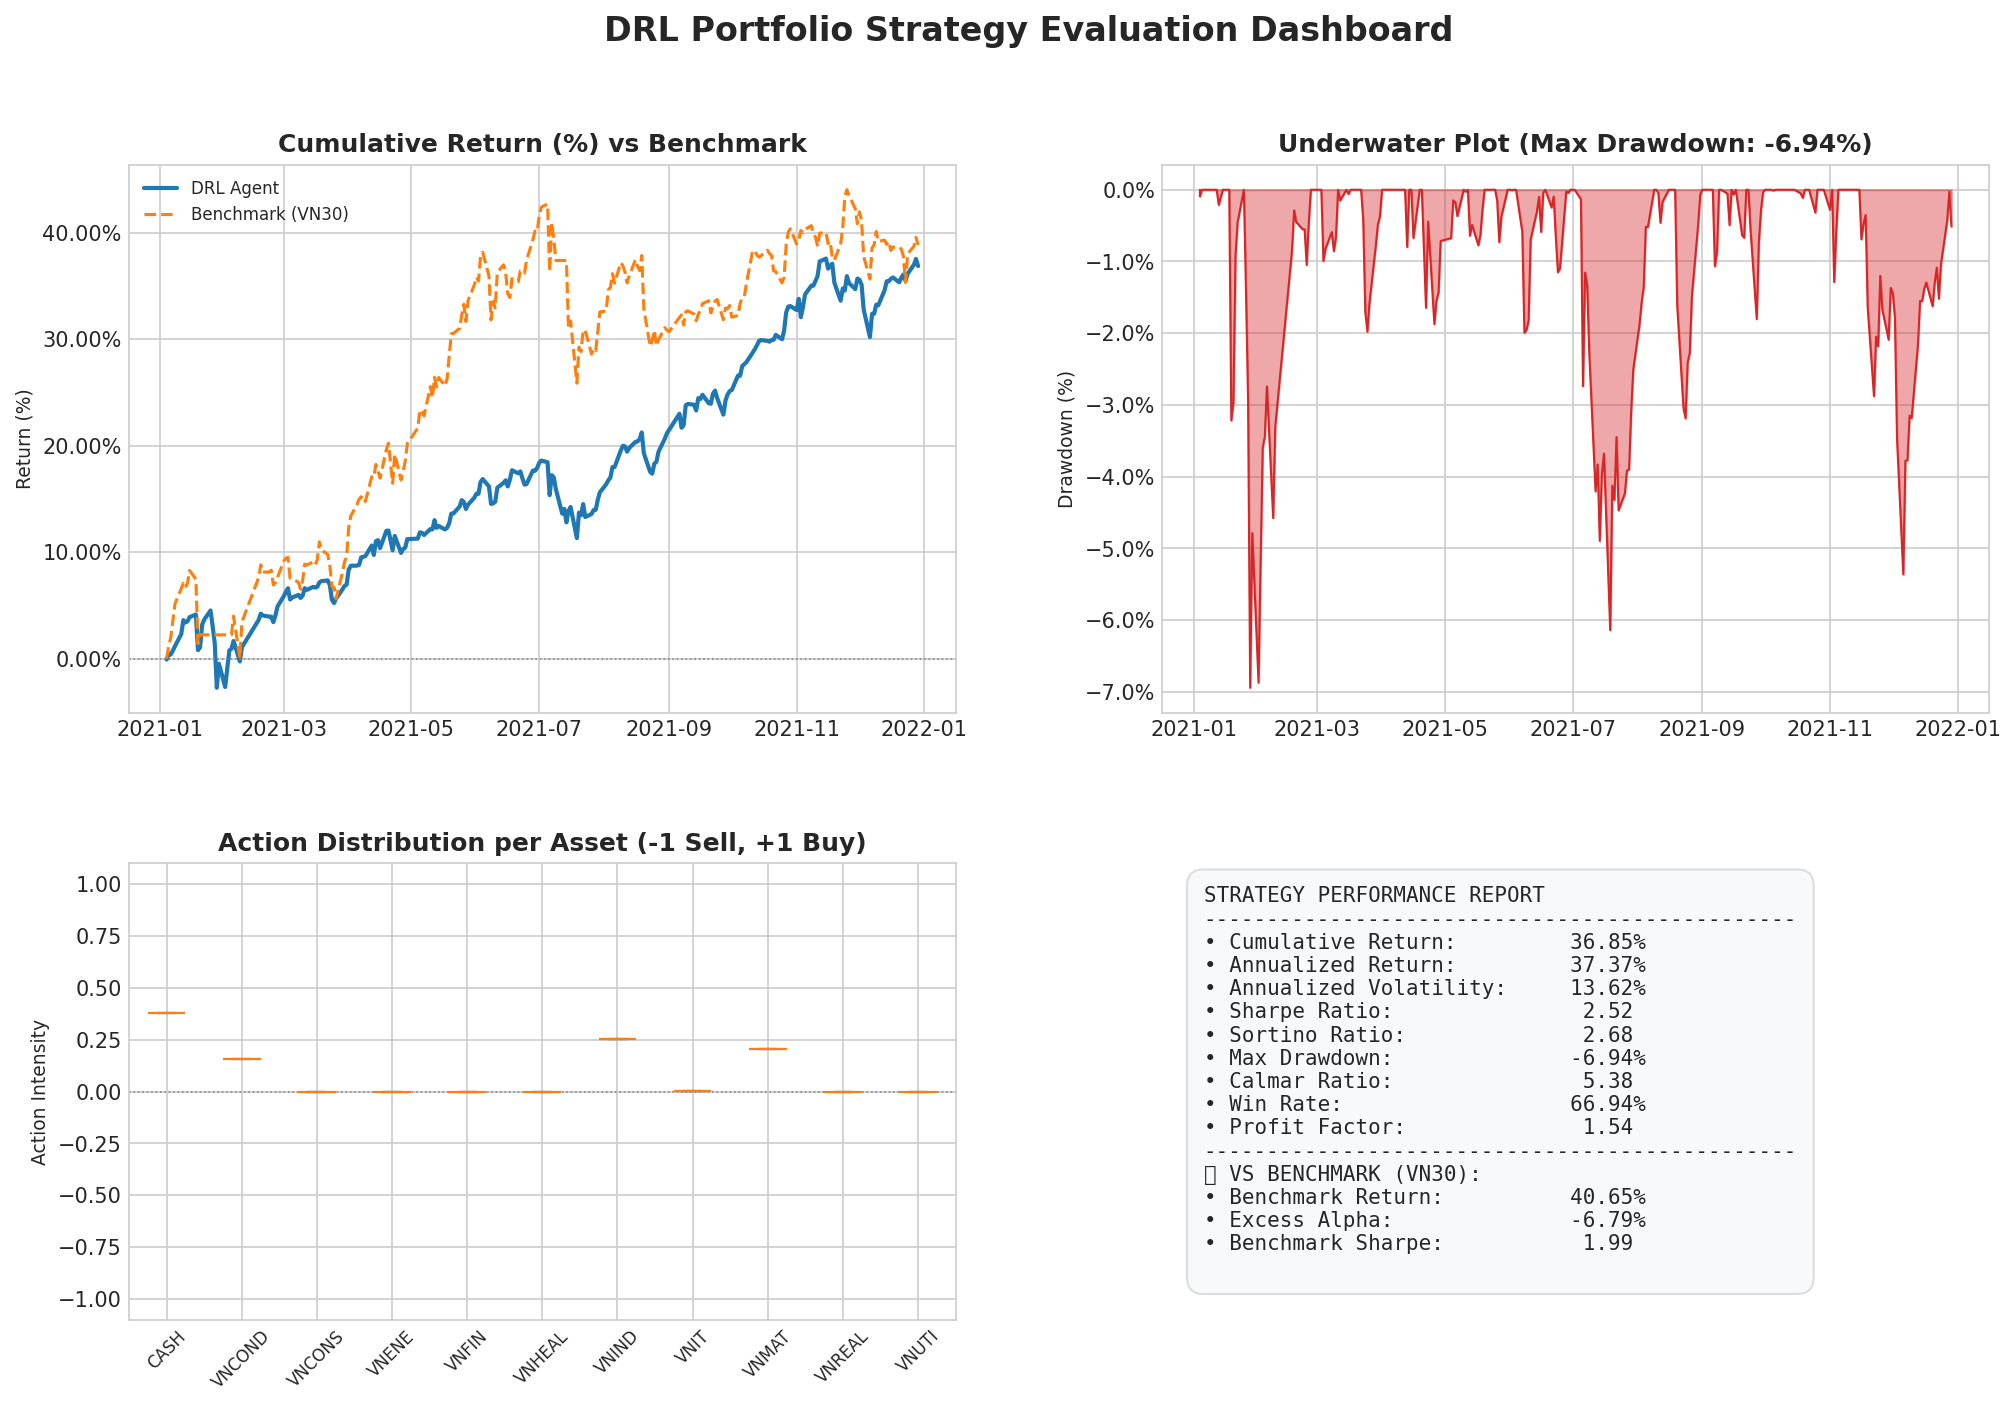

In [5]:
from model_engine.analysis.visualization import ModelVisualizer
from IPython.display import Image, display

visualizer = ModelVisualizer()

# 1. NAV Curve vs Benchmark
nav_path = visualizer.plot_nav_vs_benchmark(df_account, df_benchmark=vn30_df, benchmark_name="VN30", save_name="notebook_nav_vs_vn30.png")

# 2. Underwater / Drawdown Plot
underwater_path = visualizer.plot_underwater(df_account, save_name="notebook_underwater.png")

# 3. Action Distribution per Ticker
action_path = visualizer.plot_action_distribution(df_actions, save_name="notebook_action_dist.png")

# 4. Full Evaluation Dashboard
dashboard_path, _ = visualizer.plot_summary_dashboard(df_account, df_actions, df_benchmark=vn30_df, benchmark_name="VN30", save_name="notebook_summary_dashboard.png")

print("HIỂN THỊ EVALUATION DASHBOARD:")
display(Image(filename=dashboard_path))